<small>This code was made by [Riccardo Campi](https://scholar.google.com/citations?user=JWSoz7EAAAAJ&hl=it), Politecnico di Milano, Data Science Lab.</small>
<br><small>Thanks to [Vincent Belz](https://github.com/vbelz) for inspiring this notebook.</small>

## Library Imports and CSV Loading

We import the necessary libraries for data analysis and visualization, then load the `real‑estate dataset` dataset from a CSV file.

In [15]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('./datasets/outlier_detection_dataset.csv')

## 3. Outliers

This section focuses on identifying and handling outliers in the dataset.

> Outliers are data points that differ significantly from other observations and can potentially skew the results of our analysis.

We will use various techniques to detect outliers, such as visualizations (histograms, box plots) and statistical methods (IQR, percentiles). Once identified, we will discuss strategies for handling outliers, including removal or transformation.

In [16]:
# Print the first few rows of the dataset
data.head() 

,rooms,garages,useful_area,value,interior_quality,time_on_market,has_outlier
0,3.0,1.0,105.0,1038640.0,2,31.787079,0
1,3.0,2.0,76.0,606405.0,4,209.468842,0
2,3.0,1.0,123.0,1534500.0,1,38.000000,0
3,3.0,2.0,180.0,1131950.0,5,154.000000,0
4,3.0,1.0,67.0,452672.0,4,15.000000,0


### 3.1 Visualizing Outliers

We can use visualizations to identify outliers in our dataset.

#### 3.1.1 Box Plots

Box plots are an effective way to visualize the distribution of a variable and identify outliers. We will create box plots for the `value`, `useful_area`, `time_on_market`, `interior_quality`, `rooms`, and `garages` variables to visually inspect for outliers.

> In a box plot, outliers are typically represented as individual points that fall outside the whiskers of the box. The box itself represents the interquartile range (IQR), which contains the middle 50% of the data, while the whiskers extend to 1.5 times the IQR. Any points beyond this range are considered outliers.

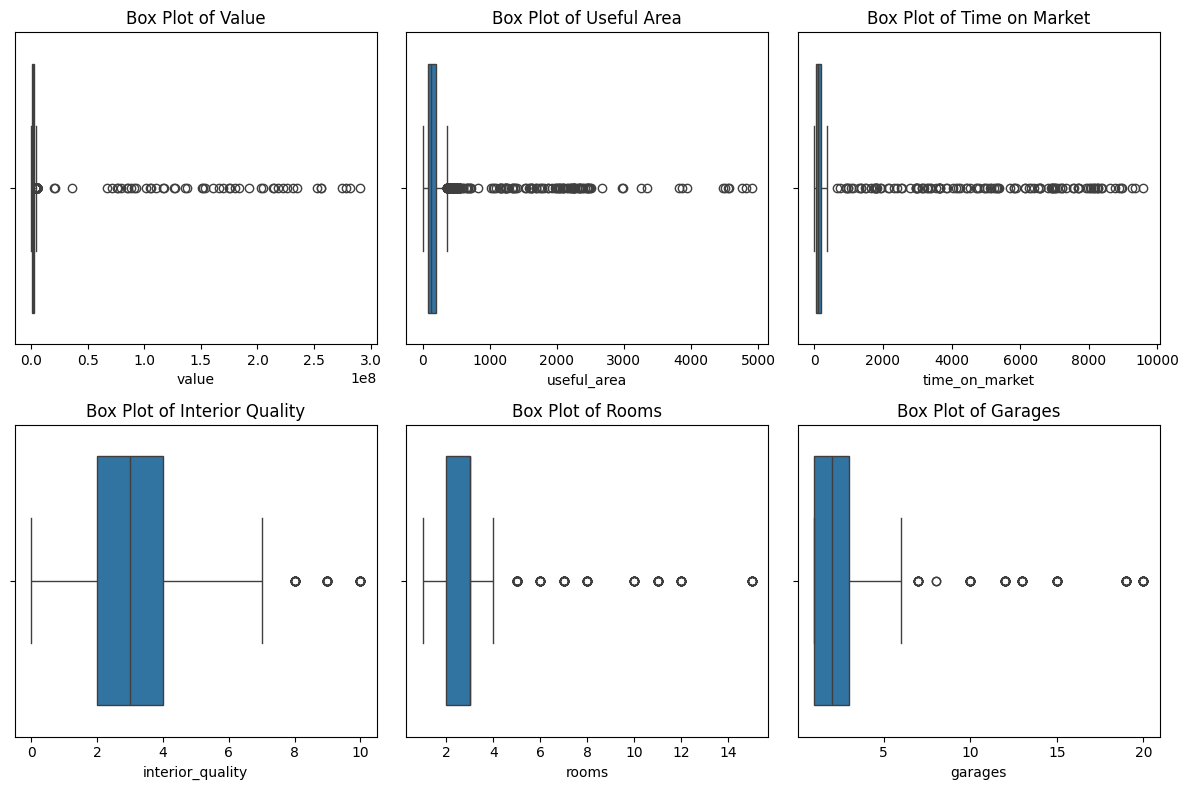

In [17]:
# Create box plots for the 'value', 'useful_area', 'time_on_market', 'interior_quality',
# 'rooms', and 'garages' variables to visually inspect for outliers
plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
sns.boxplot(x=data['value'])
plt.title('Box Plot of Value')
plt.subplot(2, 3, 2)
sns.boxplot(x=data['useful_area'])
plt.title('Box Plot of Useful Area')
plt.subplot(2, 3, 3)
sns.boxplot(x=data['time_on_market'])
plt.title('Box Plot of Time on Market')
plt.subplot(2, 3, 4)
sns.boxplot(x=data['interior_quality'])
plt.title('Box Plot of Interior Quality')
plt.subplot(2, 3, 5)
sns.boxplot(x=data['rooms'])
plt.title('Box Plot of Rooms')
plt.subplot(2, 3, 6)
sns.boxplot(x=data['garages'])
plt.title('Box Plot of Garages')
plt.tight_layout()
plt.show()

#### 3.1.2 Histograms

We will create a histogram to visualize the distribution of the `value` variable, which may contain outliers.
<br>Then, we will filter out the outliers (based on the IQR) and create another histogram to see how the distribution changes without them.

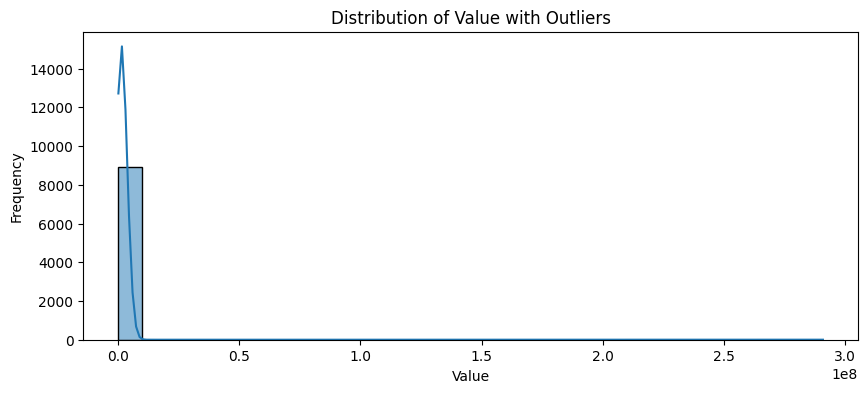

In [18]:
# Plot the distribution (with kde) of the 'value' variable WITH OUTLIERS
plt.figure(figsize=(10, 4))
sns.histplot(data['value'], kde=True, bins=30)
plt.title('Distribution of Value with Outliers')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

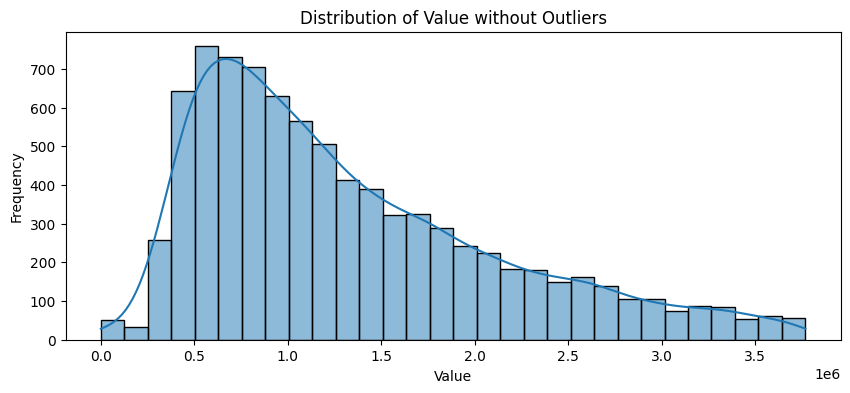

In [19]:
# Compute the interquartile range (IQR) to identify outliers
Q1 = data['value'].quantile(0.25)
Q3 = data['value'].quantile(0.75)
IQR = Q3 - Q1

# Filter out the outliers
data['value_no_outliers'] = data['value'].loc[(data['value'] > Q1 - 1.5 * IQR) & (data['value'] < Q3 + 1.5 * IQR)]

# Plot the distribution (with kde) of the 'value' variable WITHOUT OUTLIERS
plt.figure(figsize=(10, 4))
sns.histplot(data['value_no_outliers'], kde=True, bins=30)
plt.title('Distribution of Value without Outliers')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

Let's do the same for the `useful_area` variable.

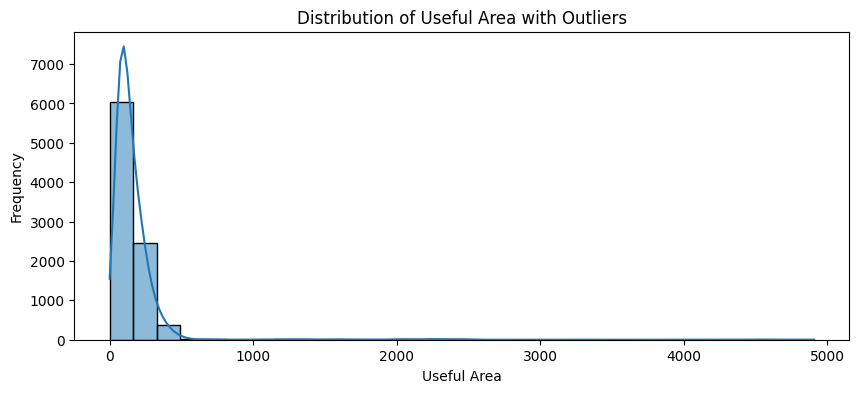

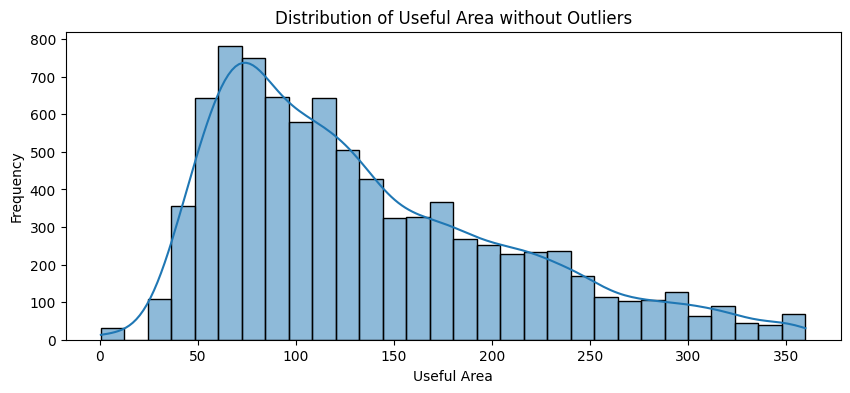

In [20]:
# Plot the distribution (with kde) of the 'useful_area' variable WITH OUTLIERS
plt.figure(figsize=(10, 4))
sns.histplot(data['useful_area'], kde=True, bins=30)
plt.title('Distribution of Useful Area with Outliers')
plt.xlabel('Useful Area')
plt.ylabel('Frequency')
plt.show()

# Compute the interquartile range (IQR) to identify outliers for 'useful_area'
Q1_area = data['useful_area'].quantile(0.25)
Q3_area = data['useful_area'].quantile(0.75)
IQR_area = Q3_area - Q1_area

# Filter out the outliers for 'useful_area'
data['useful_area_no_outliers'] = data['useful_area'].loc[(data['useful_area'] > Q1_area - 1.5 * IQR_area) & (data['useful_area'] < Q3_area + 1.5 * IQR_area)]

# Plot the distribution (with kde) of the 'useful_area' variable WITHOUT OUTLIERS
plt.figure(figsize=(10, 4))
sns.histplot(data['useful_area_no_outliers'], kde=True, bins=30)
plt.title('Distribution of Useful Area without Outliers')
plt.xlabel('Useful Area')
plt.ylabel('Frequency')
plt.show()

Let's do the same with the `time_on_market` variable.

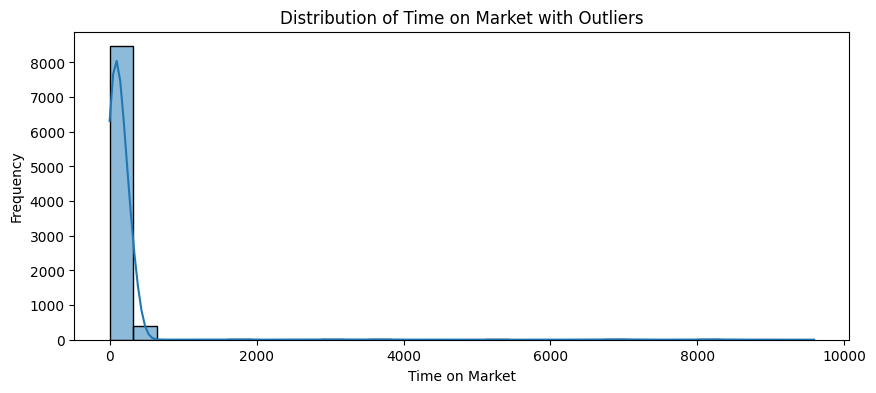

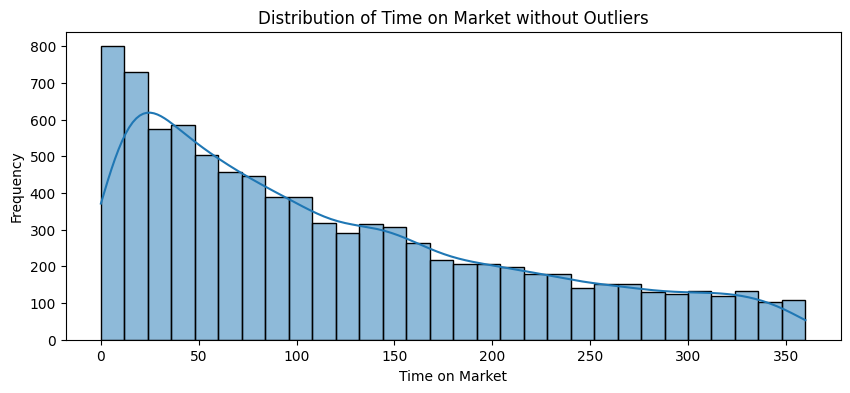

In [21]:
# Plot the distribution (with kde) of the 'time_on_market' variable WITH OUTLIERS
plt.figure(figsize=(10, 4))
sns.histplot(data['time_on_market'], kde=True, bins=30)
plt.title('Distribution of Time on Market with Outliers')
plt.xlabel('Time on Market')
plt.ylabel('Frequency')
plt.show()

# Compute the interquartile range (IQR) to identify outliers for 'time_on_market'
Q1_time = data['time_on_market'].quantile(0.25)
Q3_time = data['time_on_market'].quantile(0.75)
IQR_time = Q3_time - Q1_time

# Filter out the outliers for 'time_on_market'
data['time_on_market_no_outliers'] = data['time_on_market'].loc[(data['time_on_market'] > Q1_time - 1.5 * IQR_time) & (data['time_on_market'] < Q3_time + 1.5 * IQR_time)]

# Plot the distribution (with kde) of the 'time_on_market' variable WITHOUT OUTLIERS
plt.figure(figsize=(10, 4))
sns.histplot(data['time_on_market_no_outliers'], kde=True, bins=30)
plt.title('Distribution of Time on Market without Outliers')
plt.xlabel('Time on Market')
plt.ylabel('Frequency')
plt.show()

Let's do the same for the `interior_quality` variable, which is an integer.

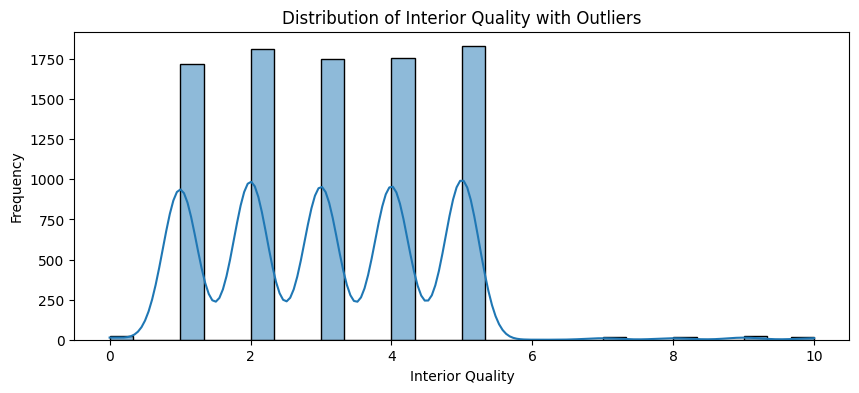

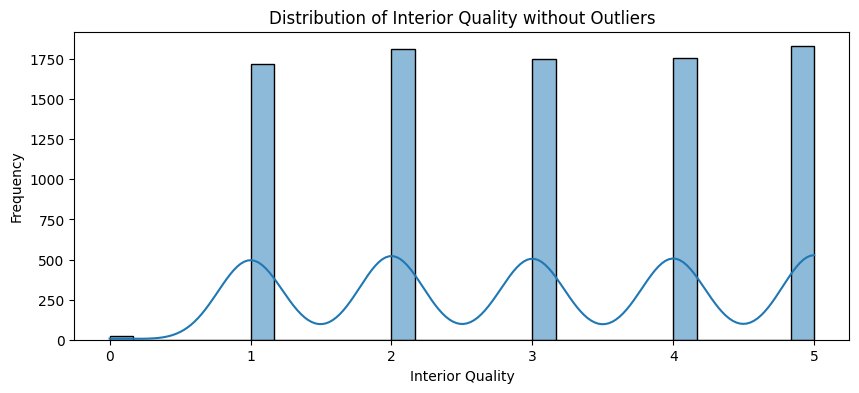

In [22]:
# Plot the distribution (with kde) of the 'interior_quality' variable WITH OUTLIERS
plt.figure(figsize=(10, 4))
sns.histplot(data['interior_quality'], kde=True, bins=30)
plt.title('Distribution of Interior Quality with Outliers')
plt.xlabel('Interior Quality')
plt.ylabel('Frequency')
plt.show()

# Compute the interquartile range (IQR) to identify outliers for 'interior_quality'
Q1_quality = data['interior_quality'].quantile(0.25)
Q3_quality = data['interior_quality'].quantile(0.75)
IQR_quality = Q3_quality - Q1_quality

# Filter out the outliers for 'interior_quality'
data['interior_quality_no_outliers'] = data['interior_quality'].loc[(data['interior_quality'] > Q1_quality - 1.5 * IQR_quality) & (data['interior_quality'] < Q3_quality + 1.5 * IQR_quality)]

# Plot the distribution (with kde) of the 'interior_quality' variable WITHOUT OUTLIERS
plt.figure(figsize=(10, 4))
sns.histplot(data['interior_quality_no_outliers'], kde=True, bins=30)
plt.title('Distribution of Interior Quality without Outliers')
plt.xlabel('Interior Quality')
plt.ylabel('Frequency')
plt.show()

Let's do the same for the `rooms` variable.

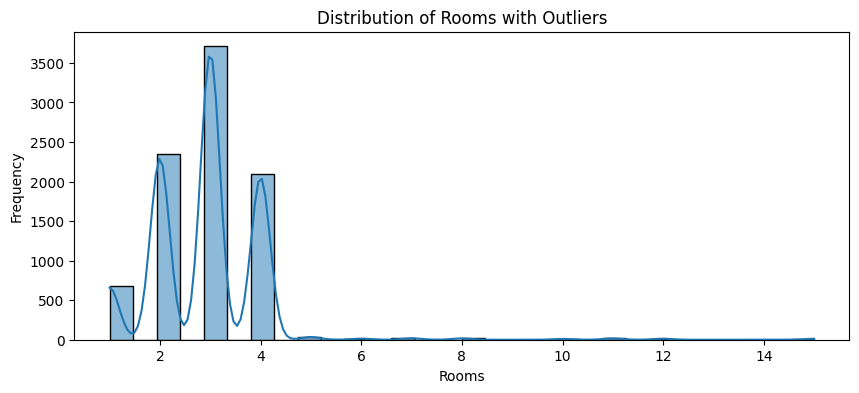

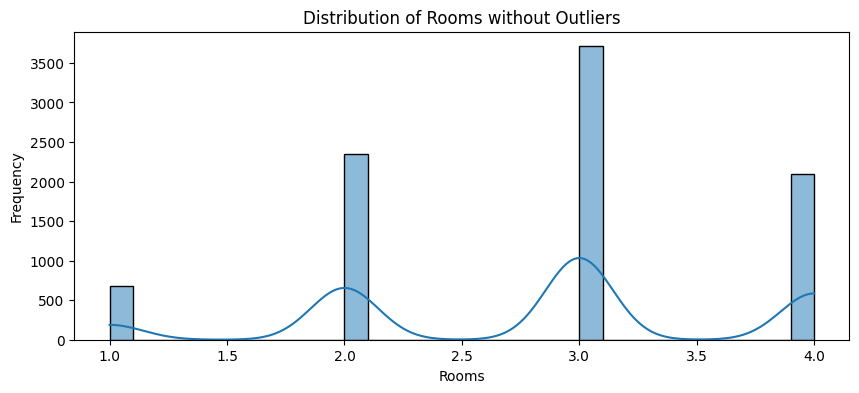

In [23]:
# Plot the distribution (with kde) of the 'rooms' variable WITH OUTLIERS
plt.figure(figsize=(10, 4))
sns.histplot(data['rooms'], kde=True, bins=30)
plt.title('Distribution of Rooms with Outliers')
plt.xlabel('Rooms')
plt.ylabel('Frequency')
plt.show()

# Compute the interquartile range (IQR) to identify outliers for 'rooms'
Q1_rooms = data['rooms'].quantile(0.25)
Q3_rooms = data['rooms'].quantile(0.75)
IQR_rooms = Q3_rooms - Q1_rooms

# Filter out the outliers for 'rooms'
data['rooms_no_outliers'] = data['rooms'].loc[(data['rooms'] > Q1_rooms - 1.5 * IQR_rooms) & (data['rooms'] < Q3_rooms + 1.5 * IQR_rooms)]

# Plot the distribution (with kde) of the 'rooms' variable WITHOUT OUTLIERS
plt.figure(figsize=(10, 4))
sns.histplot(data['rooms_no_outliers'], kde=True, bins=30)
plt.title('Distribution of Rooms without Outliers')
plt.xlabel('Rooms')
plt.ylabel('Frequency')
plt.show()

Finally, let's do the same for the `garages` variable.

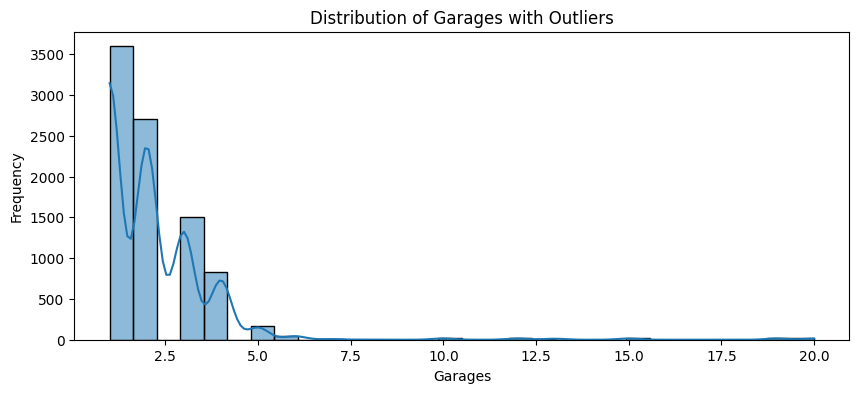

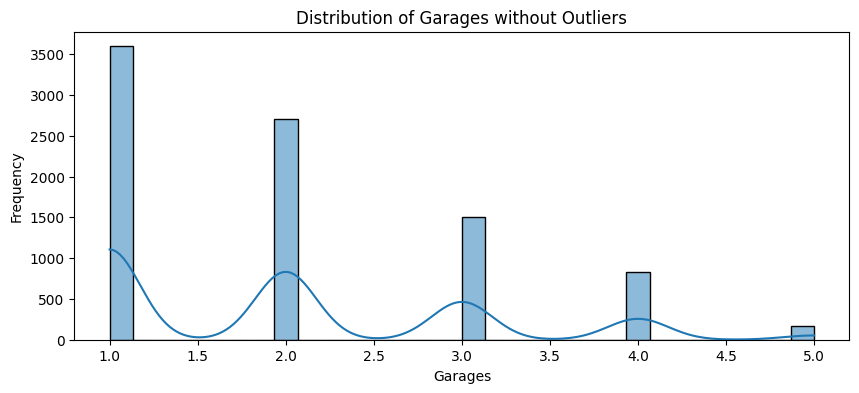

In [24]:
# Plot the distribution (with kde) of the 'garages' variable WITH OUTLIERS
plt.figure(figsize=(10, 4))
sns.histplot(data['garages'], kde=True, bins=30)
plt.title('Distribution of Garages with Outliers')
plt.xlabel('Garages')
plt.ylabel('Frequency')
plt.show()

# Compute the interquartile range (IQR) to identify outliers for 'garages'
Q1_garages = data['garages'].quantile(0.25)
Q3_garages = data['garages'].quantile(0.75)
IQR_garages = Q3_garages - Q1_garages

# Filter out the outliers for 'garages'
data['garages_no_outliers'] = data['garages'].loc[(data['garages'] > Q1_garages - 1.5 * IQR_garages) & (data['garages'] < Q3_garages + 1.5 * IQR_garages)]

# Plot the distribution (with kde) of the 'garages' variable WITHOUT OUTLIERS
plt.figure(figsize=(10, 4))
sns.histplot(data['garages_no_outliers'], kde=True, bins=30)
plt.title('Distribution of Garages without Outliers')
plt.xlabel('Garages')
plt.ylabel('Frequency')
plt.show()

### 3.2 Handling Outliers

After identifying outliers, we can choose to handle them in various ways:
- **Removing Outliers (Trimming)**: We can remove outliers from the dataset, but this may lead to loss of valuable information if not done carefully.
- **Capping Outliers (Winsorizing)**: We can cap outliers at a certain threshold to limit their influence without completely removing them.

#### 3.2.1 Removing Outliers (Trimming)
We can remove outliers from the dataset based on the IQR method.
<br>This involves calculating the first quartile (Q1), third quartile (Q3), and the interquartile range (IQR).
<br>We then filter out any data points that fall outside the range of Q1 - 1.5 * IQR and Q3 + 1.5 * IQR.

In [25]:
# Remove the outliers from the dataset
data_no_outliers = data.loc[(data['value'] > Q1 - 1.5 * IQR) & (data['value'] < Q3 + 1.5 * IQR) &
                            (data['useful_area'] > Q1_area - 1.5 * IQR_area) & (data['useful_area'] < Q3_area + 1.5 * IQR_area) & 
                            (data['time_on_market'] > Q1_time - 1.5 * IQR_time) & (data['time_on_market'] < Q3_time + 1.5 * IQR_time) &
                            (data['interior_quality'] > Q1_quality - 1.5 * IQR_quality) & (data['interior_quality'] < Q3_quality + 1.5 * IQR_quality) &
                            (data['rooms'] > Q1_rooms - 1.5 * IQR_rooms) & (data['rooms'] < Q3_rooms + 1.5 * IQR_rooms) &
                            (data['garages'] > Q1_garages - 1.5 * IQR_garages) & (data['garages'] < Q3_garages + 1.5 * IQR_garages)]

We will now inspect the box plots for the variables with outliers removed to visually confirm that the outliers have been successfully removed and to check for any remaining outliers.

> Remaining outliers may still exist after the initial removal process, and this is completely normal and expected. This is because the removal changes Q1, Q3, and IQR, which can lead to new outliers being identified based on the updated thresholds.

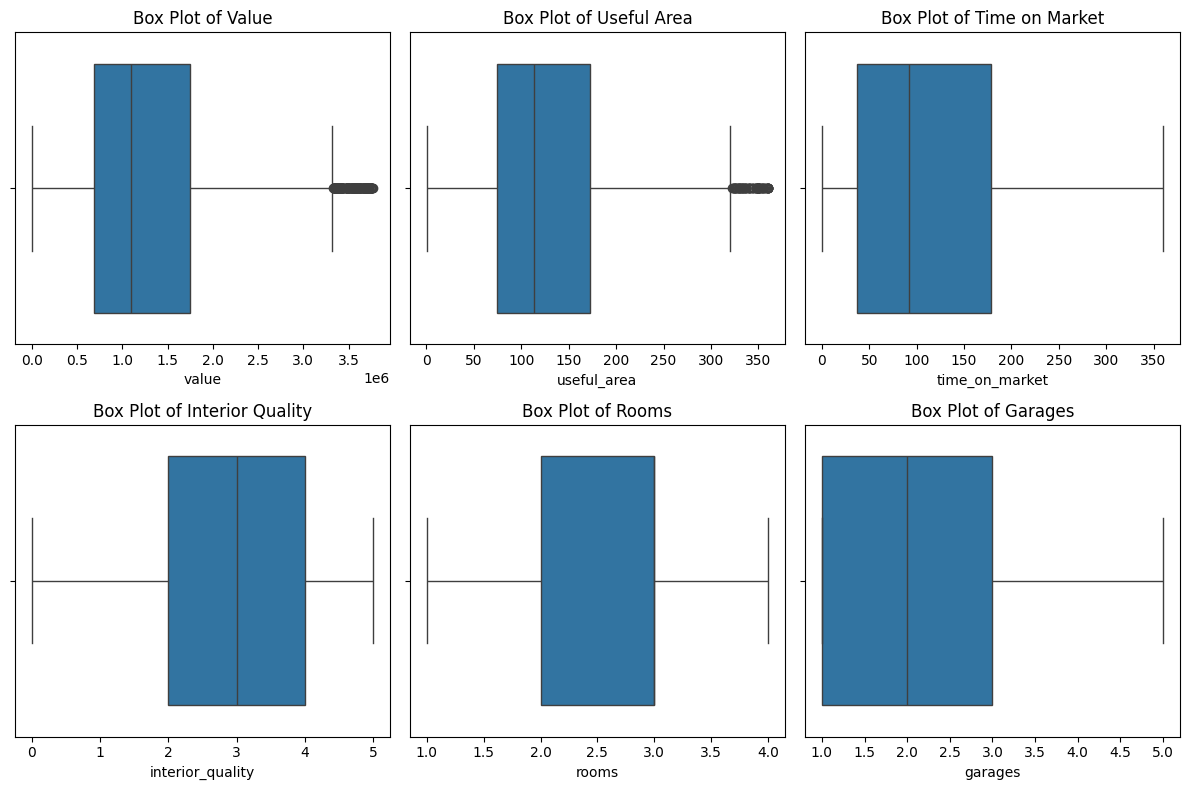

In [26]:
# Create box plots for the variables with outliers removed to visually inspect for REMAINING outliers
plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
sns.boxplot(x=data_no_outliers['value'])
plt.title('Box Plot of Value')
plt.subplot(2, 3, 2)
sns.boxplot(x=data_no_outliers['useful_area'])
plt.title('Box Plot of Useful Area')
plt.subplot(2, 3, 3)
sns.boxplot(x=data_no_outliers['time_on_market'])
plt.title('Box Plot of Time on Market')
plt.subplot(2, 3, 4)
sns.boxplot(x=data_no_outliers['interior_quality'])
plt.title('Box Plot of Interior Quality')
plt.subplot(2, 3, 5)
sns.boxplot(x=data_no_outliers['rooms'])
plt.title('Box Plot of Rooms')
plt.subplot(2, 3, 6)
sns.boxplot(x=data_no_outliers['garages'])
plt.title('Box Plot of Garages')
plt.tight_layout()
plt.show()


#### 3.2.2 Capping Outliers (Winsorizing)
Instead of removing outliers, we can cap them at a certain threshold.
<br>For example, we can apply a 10% Winsorization, which means that any data point above the 95th percentile will be set to the value at the 95th percentile, and any data point below the 5th percentile will be set to the value at the 5th percentile.
<br>This way, we retain all data points while limiting the influence of extreme values on our analysis.

In [27]:
# Cap the outliers in the original dataset using a 10% winsorization (95th and 5th percentiles)
data_winsorized = data.copy()
data_winsorized['value'] = data_winsorized['value'].clip(lower=data_winsorized['value'].quantile(0.05), upper=data_winsorized['value'].quantile(0.95))
data_winsorized['useful_area'] = data_winsorized['useful_area'].clip(lower=data_winsorized['useful_area'].quantile(0.05), upper=data_winsorized['useful_area'].quantile(0.95))
data_winsorized['time_on_market'] = data_winsorized['time_on_market'].clip(lower=data_winsorized['time_on_market'].quantile(0.05), upper=data_winsorized['time_on_market'].quantile(0.95))
data_winsorized['interior_quality'] = data_winsorized['interior_quality'].clip(lower=data_winsorized['interior_quality'].quantile(0.05), upper=data_winsorized['interior_quality'].quantile(0.95))
data_winsorized['rooms'] = data_winsorized['rooms'].clip(lower=data_winsorized['rooms'].quantile(0.05), upper=data_winsorized['rooms'].quantile(0.95))
data_winsorized['garages'] = data_winsorized['garages'].clip(lower=data_winsorized['garages'].quantile(0.05), upper=data_winsorized['garages'].quantile(0.95))

Let's inspect the box plots for the variables with outliers capped to visually confirm that the extreme values have been limited and to check for any remaining outliers.

> Since winsorizing caps extreme values instead of removing them, it preserves the central distribution (Q1, Q3, IQR) and keeps the boxplot fences almost unchanged. This leads to fewer new outliers being identified compared to the trimming method.

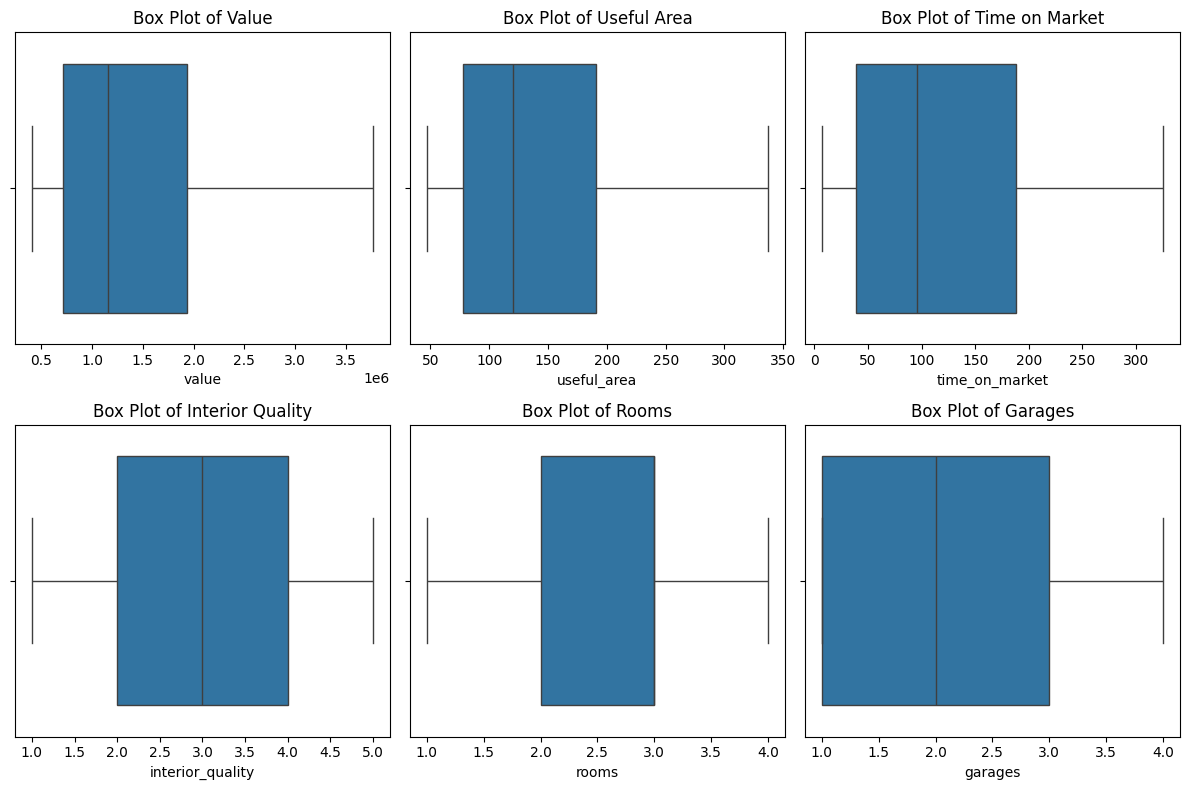

In [28]:
# Create box plots for the variables with outliers removed to visually inspect for REMAINING outliers
plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
sns.boxplot(x=data_winsorized['value'])
plt.title('Box Plot of Value')
plt.subplot(2, 3, 2)
sns.boxplot(x=data_winsorized['useful_area'])
plt.title('Box Plot of Useful Area')
plt.subplot(2, 3, 3)
sns.boxplot(x=data_winsorized['time_on_market'])
plt.title('Box Plot of Time on Market')
plt.subplot(2, 3, 4)
sns.boxplot(x=data_winsorized['interior_quality'])
plt.title('Box Plot of Interior Quality')
plt.subplot(2, 3, 5)
sns.boxplot(x=data_winsorized['rooms'])
plt.title('Box Plot of Rooms')
plt.subplot(2, 3, 6)
sns.boxplot(x=data_winsorized['garages'])
plt.title('Box Plot of Garages')
plt.tight_layout()
plt.show()